# Two plots:
- Total variation bar chart — deltacon, energy, frobenius
- Minima scatter — top-100 per individual subject, subjects shaded by intensity of dataset color

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

from vizman import viz
viz.set_visual_style()

# CONFIG
base_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")
output_path = Path(".") 

from config import COLOR_SCHEME

# η / γ normalisation bounds (same as original script)
ETA_MIN, ETA_MAX     = -3, 8
GAMMA_MIN, GAMMA_MAX = -0.1, 1


# Distance measures for both plots
DISTANCE_MEASURES_DICT = {"delta_con": "DeltaCon", 
                     "energy": "Energy", 
                     "frobenius": "Frobenius"} 

DISTANCE_MEASURES = DISTANCE_MEASURES_DICT.keys()
DISTANCE_NAME_IN_CSV = {
    "delta_con":  "DeltaCon",
    "energy":    "MaxCrit",
    "frobenius": "Frobenius",
    "hamming": "HammingDist",
}

# Bar colors for the total-variation plot
MEASURE_BAR_COLORS = {
    "energy":    "#E6B213",
    "delta_con":  "#4BAE6A",
    "frobenius": "#006685", 
    "hamming":  "#394D73",
}

# CSV paths per distance measure
# Structure mirrors the new script's csv_files dict, but we need all 3 measures.
# We use the MEAN across subjects for the total-variation bar (consistent with original).
# For the minima scatter we only use "energy" (or whichever you prefer — see SCATTER_MEASURE).
SCATTER_MEASURE = "energy"   # which distance measure drives the scatter plot

def get_csv_path(dataset_key: str, experiment_suffix: str, measure: str) -> Path:
    """Build the CSV path following the project convention."""
    return (
        base_dir
        / dataset_key
        / experiment_suffix
        / f"summary_indiv_{measure}_for_exp_{experiment_suffix}.csv"
    )

# ── datasets to include in the scatter plot ───────────────────────────────────
SCATTER_DATASETS = {
    # key → (dataset_folder, experiment_suffix, dataset_color_key)
    "HCP":      ("hcp_schaefer_100_dataset",
                    "05_mst_animal_0_compared_with_hcp_schaefer_100",
                    "hcp_schaefer_100_dataset"),
    "MaMI":        ("suarez_MaMI_dataset",
                    "05_mst_animal_0_compared_with_mami",
                    "suarez_MaMI_dataset"),
    "Diffusion":   ("kaysons_generated_networks_diffusion",
                    "05_mst_animal_0_compared_with_diffusion",
                    "kaysons_generated_networks_diffusion"),
    "Propagation": ("kaysons_generated_networks_propagation",
                    "05_mst_animal_0_compared_with_propagation",
                    "kaysons_generated_networks_propagation"),
    "Routing":     ("kaysons_generated_networks_routing",
                    "05_mst_animal_0_compared_with_routing",
                    "kaysons_generated_networks_routing"),
}

# ── datasets to include in the total-variation bar chart ─────────────────────
VARIATION_DATASETS = SCATTER_DATASETS   # same set

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def lighten_color(hex_color: str, amount: float) -> tuple:
    """
    Blend hex_color toward white.
    amount=0 → original color, amount=1 → white.
    """
    rgb = mcolors.to_rgb(hex_color)
    return tuple(c + (1 - c) * amount for c in rgb)


def subject_colors(base_hex: str, n: int) -> list:
    """
    Return n colors ranging from the base color (darkest / most saturated)
    to a lighter tint, so each subject is distinguishable.
    """
    if n == 1:
        return [mcolors.to_rgb(base_hex)]
    # lighten from 0 (full color) to 0.65 (fairly light)
    return [lighten_color(base_hex, i * 0.65 / (n - 1)) for i in range(n)]


def load_and_clean(csv_path: Path) -> pd.DataFrame:
    """Load CSV and deduplicate _x/_y/_z suffixed columns."""
    df = pd.read_csv(csv_path)
    meta = {"eta", "filename", "id", "gamma", "network_index"}
    keys = set(
        k.replace("_x", "").replace("_y", "").replace("_z", "")
        for k in df.columns
    ) - meta
    all_keys = set(df.columns)
    first_versions = []
    for key in keys:
        for suffix in ("", "_x", "_y", "_z"):
            if key + suffix in all_keys:
                first_versions.append(key + suffix)
                break
    keep = first_versions + [c for c in ("eta", "id", "gamma", "network_index") if c in all_keys]
    return df[keep]


def get_df_mean(csv_p: Path, measure: str) -> pd.DataFrame:
    """Return df_mean with per-subject and mean distance columns."""
    df = load_and_clean(csv_p)
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    col_prefix = DISTANCE_NAME_IN_CSV[measure]
    subj_cols  = [c for c in df_mean.columns if f"{col_prefix}_subject_" in c]
    df_mean[f"{col_prefix}_mean"] = df_mean[subj_cols].mean(axis=1)
    return df_mean, subj_cols, col_prefix

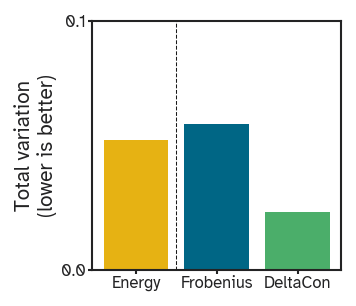

In [32]:

# TOTAL VARIATION BAR CHART
def compute_combined_variability(dataset_info: dict, measure: str, top_n: int = 100) -> float:
    """
    For a given dataset + distance measure, pick the top_n (η, γ) pairs by
    mean distance score, normalise η and γ, return combined variance.
    """
    folder, exp, _ = dataset_info
    csv_p = get_csv_path(folder, exp, measure)
    if not csv_p.exists():
        return np.nan

    df_mean, subj_cols, col_prefix = get_df_mean(csv_p, measure)
    mean_col = f"{col_prefix}_mean"

    top = df_mean.nsmallest(top_n, mean_col)
    norm_eta   = (top["eta"].values   - ETA_MIN)   / (ETA_MAX   - ETA_MIN)
    norm_gamma = (top["gamma"].values - GAMMA_MIN) / (GAMMA_MAX - GAMMA_MIN)

    return float(norm_eta.std() ** 2 + norm_gamma.std() ** 2)



fig = plt.figure(figsize=viz.cm_to_inch((6, 6)), dpi=150)
ax  = fig.add_axes([0, 0, 1, 1])

# Average variability across all datasets for each measure
bars = {}

for measure in DISTANCE_MEASURES:
    vals = []
    for ds_key, ds_info in VARIATION_DATASETS.items():
        v = compute_combined_variability(ds_info, measure)
        if not np.isnan(v):
            vals.append(v)
    bars[measure] = np.mean(vals) if vals else np.nan


# Sort: energy first, then descending
energy_val   = bars.pop("energy")
other_sorted = sorted(bars.items(), key=lambda x: x[1], reverse=True)
ordered      = [("energy", energy_val)] + other_sorted

xlabel_measures = []
for x_pos, (measure, val) in enumerate(ordered):
    xlabel_measures.append(DISTANCE_MEASURES_DICT[measure])
    ax.bar(x_pos, val, color=MEASURE_BAR_COLORS.get(measure, "gray"), label=measure)

# Vertical dashed line after "energy" bar
ax.axvline(x=0.5, linestyle="--", linewidth=0.5, color="k")

ax.set_xticks([0,1,2], xlabel_measures)
ax.set_yticks([0, 0.1])
ax.set_ylabel("Total variation\n(lower is better)")

ax_w, ax_h = viz.cm_to_inch((6, 6))
ax.set_position([0.15, 0.15, ax_w / (ax_w + 1), ax_h / (ax_h + 1)])

# fig.savefig(output_path / "total_variation_deltacon_energy_frobenius.pdf",
#             bbox_inches="tight")
# print("Saved:", output_path / "total_variation_deltacon_energy_frobenius.pdf")
# plt.close(fig)

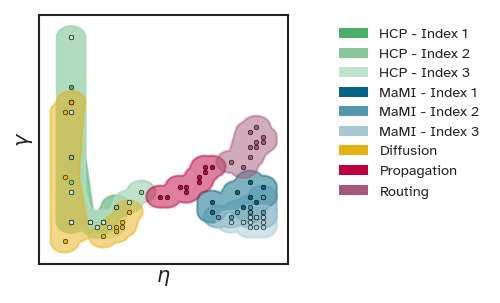

In [ ]:
# MINIMA SCATTER  (top-100 per individual subject)
from scipy.spatial import ConvexHull
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from shapely.geometry import MultiPolygon, Polygon


measure=SCATTER_MEASURE
N_DOTS = 10
    
import alphashape

OCTAGON_RADIUS = 0.025 # 5  # padding per point
ALPHA = 4 # 4 ## 2# 5.0            # higher = tighter fit; tune to taste
N_CORNERS = 50 + 1
N_SUBJECTS = 3

ETA_RANGE   = 3 - (-8)   # 11
GAMMA_RANGE = 1 - (-0.1) # 1.1
RADIUS_GAMMA = 0.05       # tune this one value in data units of gamma
RADIUS_ETA   = RADIUS_GAMMA * (ETA_RANGE / GAMMA_RANGE)  # scaled to match


def achteck_vertices(cx, cy, r):

    angles = np.linspace(0, 2 * np.pi, N_CORNERS)[:-1]
    return np.column_stack([cx + r * np.cos(angles), cy + r * np.sin(angles)])


def achteck_vertices(cx, cy, rx, ry):
    """Elliptical 'octagon' that appears circular given the axis aspect ratio."""
    angles = np.linspace(0, 2 * np.pi, N_CORNERS)[:-1]
    return np.column_stack([cx + rx * np.cos(angles),
                            cy + ry * np.sin(angles)])
    
fig = plt.figure(figsize=viz.cm_to_inch((6, 6)), dpi=150)
ax  = fig.add_axes([0, 0, 1, 1])

col_prefix = DISTANCE_NAME_IN_CSV[measure]

for ds_key, (folder, exp, color_key) in SCATTER_DATASETS.items():
    csv_p = get_csv_path(folder, exp, measure)
    if not csv_p.exists():
        print(f"  [SKIP] {csv_p} not found")
        continue

    df_mean, subj_cols, _ = get_df_mean(csv_p, measure)
    base_color = COLOR_SCHEME.get(color_key, "#888888")

    # For diffusion / propagation / routing there is only one subject
    # For humans / mami there may be many — autodetect all
    subj_cols = subj_cols[:N_SUBJECTS] if len(subj_cols) > N_SUBJECTS else subj_cols
    n_subjects = len(subj_cols)
    n_subjects = min(n_subjects, N_SUBJECTS)  # avoid zero division if no subj cols
    colors     = subject_colors(base_color, n_subjects)


    for i, (col, color) in enumerate(zip(subj_cols, colors)):
        top100 = df_mean.nsmallest(N_DOTS, col)
        x = top100["eta"].values
        y = top100["gamma"].values



        if len(x) >= 1:
            all_verts = np.vstack([achteck_vertices(cx, cy, RADIUS_ETA, RADIUS_GAMMA)
                                   for cx, cy in zip(x, y)])

            shape = alphashape.alphashape(all_verts, ALPHA)
            polys = shape.geoms if isinstance(shape, MultiPolygon) else [shape]
            for poly in polys:
                exterior = np.array(poly.exterior.coords)
                patch = plt.Polygon(exterior, color=color, alpha=0.5, zorder=1)
                ax.add_patch(patch)
                # ax.plot(exterior[:, 0], exterior[:, 1], color=color, linewidth=1)
                
        ax.scatter(x, y, color=color, s=5, # 10,
                edgecolor="black", linewidth=0.25, zorder=100)

        

ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel(r"$\gamma$")
ax.set_xlabel(r"$\eta$")





from matplotlib.patches import Patch


legend_elements = []
for ds_key, (folder, exp, color_key) in SCATTER_DATASETS.items():
    csv_p = get_csv_path(folder, exp, measure)
    if not csv_p.exists():
        continue

    df_mean, subj_cols, _ = get_df_mean(csv_p, measure)
    subj_cols = subj_cols[:3] if len(subj_cols) > 3 else subj_cols
    n_subjects = len(subj_cols)
    base_color = COLOR_SCHEME.get(color_key, "#888888")
    colors = subject_colors(base_color, n_subjects)

    if n_subjects == 1:
        legend_elements.append(Patch(facecolor=colors[0], label=ds_key))
    else:
        for i, color in enumerate(colors):
            legend_elements.append(Patch(facecolor=color, label=f"{ds_key} - Index {i+1}"))
ax.legend(
    handles=legend_elements,
    # loc="upper right",
    bbox_to_anchor=(1.15, 1),
    frameon=False,
    fontsize=7,
)



ax_w, ax_h = viz.cm_to_inch((6, 6))
ax.set_position([0.15, 0.15, ax_w / (ax_w + 1), ax_h / (ax_h + 1)])

out = output_path / f"minima_scatter_top100_per_subject_{measure}.pdf"
# fig.savefig(out, bbox_inches="tight")
# print("Saved:", out)
plt.show()

# Create this plot for every measure, to compare visually how distributed the dots are for each... 

In [34]:
DISTANCE_MEASURES

dict_keys(['delta_con', 'energy', 'frobenius'])

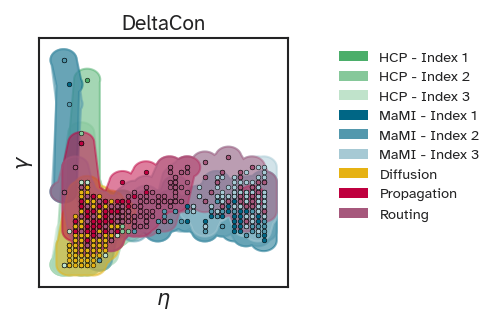

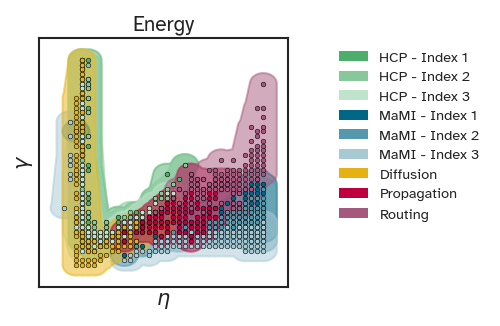

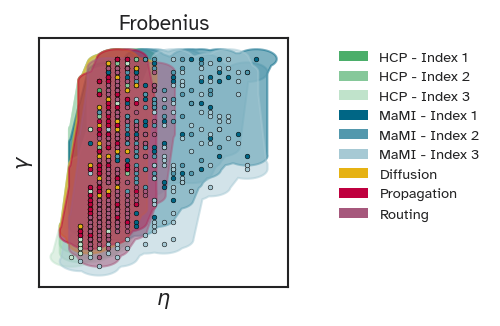

In [ ]:
N_DOTS = 100

for measure in DISTANCE_MEASURES:
    fig = plt.figure(figsize=viz.cm_to_inch((6, 6)), dpi=150)
    ax  = fig.add_axes([0, 0, 1, 1])
    
        
    col_prefix = DISTANCE_NAME_IN_CSV[measure]

    for ds_key, (folder, exp, color_key) in SCATTER_DATASETS.items():
        csv_p = get_csv_path(folder, exp, measure)
        if not csv_p.exists():
            print(f"  [SKIP] {csv_p} not found")
            continue

        df_mean, subj_cols, _ = get_df_mean(csv_p, measure)
        base_color = COLOR_SCHEME.get(color_key, "#888888")

        # For diffusion / propagation / routing there is only one subject
        # For humans / mami there may be many — autodetect all
        subj_cols = subj_cols[:N_SUBJECTS] if len(subj_cols) > N_SUBJECTS else subj_cols
        n_subjects = len(subj_cols)
        n_subjects = min(n_subjects, N_SUBJECTS)  # avoid zero division if no subj cols
        colors     = subject_colors(base_color, n_subjects)


        for i, (col, color) in enumerate(zip(subj_cols, colors)):
            top100 = df_mean.nsmallest(N_DOTS, col)
            x = top100["eta"].values
            y = top100["gamma"].values



            if len(x) >= 1:
                all_verts = np.vstack([achteck_vertices(cx, cy, RADIUS_ETA, RADIUS_GAMMA)
                                    for cx, cy in zip(x, y)])

                shape = alphashape.alphashape(all_verts, ALPHA)
                polys = shape.geoms if isinstance(shape, MultiPolygon) else [shape]
                for poly in polys:
                    exterior = np.array(poly.exterior.coords)
                    patch = plt.Polygon(exterior, color=color, alpha=0.5, zorder=1)
                    ax.add_patch(patch)
                    # ax.plot(exterior[:, 0], exterior[:, 1], color=color, linewidth=1)
                    
            ax.scatter(x, y, color=color, s=5, # 10,
                    edgecolor="black", linewidth=0.25, zorder=100)

            

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(r"$\gamma$")
    ax.set_xlabel(r"$\eta$")

    legend_elements = []
    for ds_key, (folder, exp, color_key) in SCATTER_DATASETS.items():
        csv_p = get_csv_path(folder, exp, measure)
        if not csv_p.exists():
            print("cont")
            continue

        df_mean, subj_cols, _ = get_df_mean(csv_p, measure)
        subj_cols = subj_cols[:3] if len(subj_cols) > 3 else subj_cols
        n_subjects = len(subj_cols)
        base_color = COLOR_SCHEME.get(color_key, "#888888")
        colors = subject_colors(base_color, n_subjects)

        if n_subjects == 1:
            legend_elements.append(Patch(facecolor=colors[0], label=ds_key))
        else:
            for i, color in enumerate(colors):
                legend_elements.append(Patch(facecolor=color, label=f"{ds_key} - Index {i+1}"))

    ax.legend(
        handles=legend_elements,
        # loc="upper right",
        bbox_to_anchor=(1.15, 1),
        frameon=False,
        fontsize=7,
    )
    
    plt.title(f"{DISTANCE_MEASURES_DICT[measure]}") # .replace(" ", "")}")



    ax_w, ax_h = viz.cm_to_inch((6, 6))
    ax.set_position([0.15, 0.15, ax_w / (ax_w + 1), ax_h / (ax_h + 1)])

    out = output_path / f"minima_scatter_top100_per_subject_{measure}.pdf"
    # fig.savefig(out, bbox_inches="tight")
    # print("Saved:", out)
    plt.show()

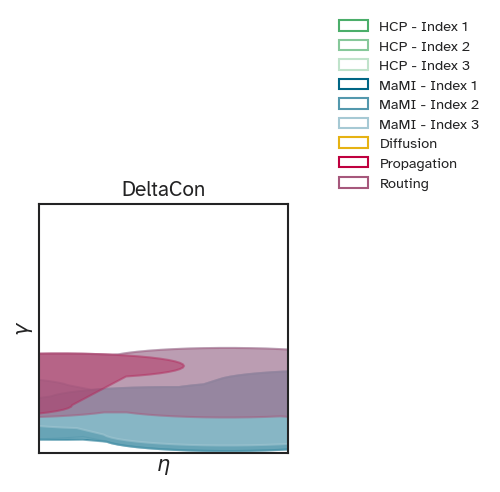

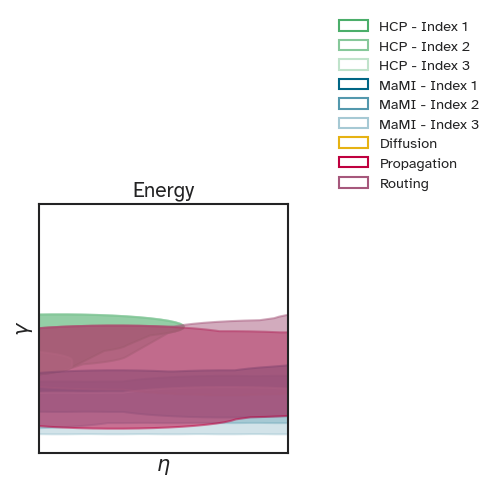

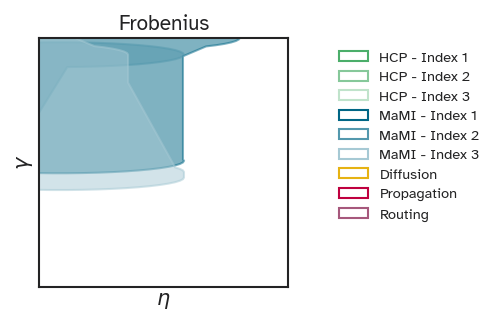

In [44]:
N_DOTS = 100

for measure in DISTANCE_MEASURES:
    fig = plt.figure(figsize=viz.cm_to_inch((6, 6)), dpi=150)
    ax  = fig.add_axes([0, 0, 1, 1])
    
        
    col_prefix = DISTANCE_NAME_IN_CSV[measure]

    for ds_key, (folder, exp, color_key) in SCATTER_DATASETS.items():
        csv_p = get_csv_path(folder, exp, measure)
        if not csv_p.exists():
            print(f"  [SKIP] {csv_p} not found")
            continue

        df_mean, subj_cols, _ = get_df_mean(csv_p, measure)
        base_color = COLOR_SCHEME.get(color_key, "#888888")

        # For diffusion / propagation / routing there is only one subject
        # For humans / mami there may be many — autodetect all
        subj_cols = subj_cols[:N_SUBJECTS] if len(subj_cols) > N_SUBJECTS else subj_cols
        n_subjects = len(subj_cols)
        n_subjects = min(n_subjects, N_SUBJECTS)  # avoid zero division if no subj cols
        colors     = subject_colors(base_color, n_subjects)


        for i, (col, color) in enumerate(zip(subj_cols, colors)):
            top100 = df_mean.nsmallest(N_DOTS, col)
            x = top100["eta"].values
            y = top100["gamma"].values



            if len(x) >= 1:
                all_verts = np.vstack([achteck_vertices(cx, cy, RADIUS_ETA, RADIUS_GAMMA)
                                    for cx, cy in zip(x, y)])

                shape = alphashape.alphashape(all_verts, ALPHA)
                polys = shape.geoms if isinstance(shape, MultiPolygon) else [shape]
                for poly in polys:
                    exterior = np.array(poly.exterior.coords)
                    patch = plt.Polygon(exterior, color=color, alpha=0.5, zorder=1)
                    ax.add_patch(patch)
                    # ax.plot(exterior[:, 0], exterior[:, 1], color=color, linewidth=1)
                    
            # ax.scatter(x, y, color=color, s=5, # 10,
            #         edgecolor="black", linewidth=0.25, zorder=100)

            

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(r"$\gamma$")
    ax.set_xlabel(r"$\eta$")

    legend_elements = []
    for ds_key, (folder, exp, color_key) in SCATTER_DATASETS.items():
        csv_p = get_csv_path(folder, exp, measure)
        if not csv_p.exists():
            print("cont")
            continue

        df_mean, subj_cols, _ = get_df_mean(csv_p, measure)
        subj_cols = subj_cols[:3] if len(subj_cols) > 3 else subj_cols
        n_subjects = len(subj_cols)
        base_color = COLOR_SCHEME.get(color_key, "#888888")
        colors = subject_colors(base_color, n_subjects)

        if n_subjects == 1:
            legend_elements.append(Patch(facecolor="none", edgecolor=colors[0], label=ds_key))
        else:
            for i, color in enumerate(colors):
                legend_elements.append(Patch(facecolor="none", edgecolor=color, label=f"{ds_key} - Index {i+1}"))

    ax.legend(
        handles=legend_elements,
        # loc="upper right",
        bbox_to_anchor=(1.15, 1),
        frameon=False,
        fontsize=7,
    )
    
    plt.title(f"{DISTANCE_MEASURES_DICT[measure]}") # .replace(" ", "")}")



    ax_w, ax_h = viz.cm_to_inch((6, 6))
    ax.set_position([0.15, 0.15, ax_w / (ax_w + 1), ax_h / (ax_h + 1)])

    out = output_path / f"minima_scatter_top100_per_subject_{measure}.pdf"
    # fig.savefig(out, bbox_inches="tight")
    # print("Saved:", out)
    plt.show()

# OLD

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from vizman import viz

base_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")
distance_measure = "energy" # "hamming" # delta_con
distance_name_in_csv_dict = {
    "hamming": "HammingDist", 
    "delta_con": "DeltaCon", 
    "energy": "MaxCrit"
}
distance_name_in_csv = distance_name_in_csv_dict[distance_measure]

csv_files = {
    'humans': base_dir / f"hcp_schaefer_100_dataset/05_mst_animal_0_compared_with_hcp_schaefer_100/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_hcp_schaefer_100.csv",
    'diffusion': base_dir / f"kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusion/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_diffusion.csv",
    'propagation': base_dir / f"kaysons_generated_networks_propagation/05_mst_animal_0_compared_with_propagation/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_propagation.csv",
    'routing': base_dir / f"kaysons_generated_networks_routing/05_mst_animal_0_compared_with_routing/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_routing.csv",
    'mami': base_dir / f"suarez_MaMI_dataset/05_mst_animal_0_compared_with_mami/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_mami.csv"
}


Processing humans...
104
  Found 100 minima
Processing diffusion...
5
  Found 1 minima
Processing propagation...
5
  Found 1 minima
Processing routing...
5
  Found 1 minima
Processing mami...
228
  Found 224 minima


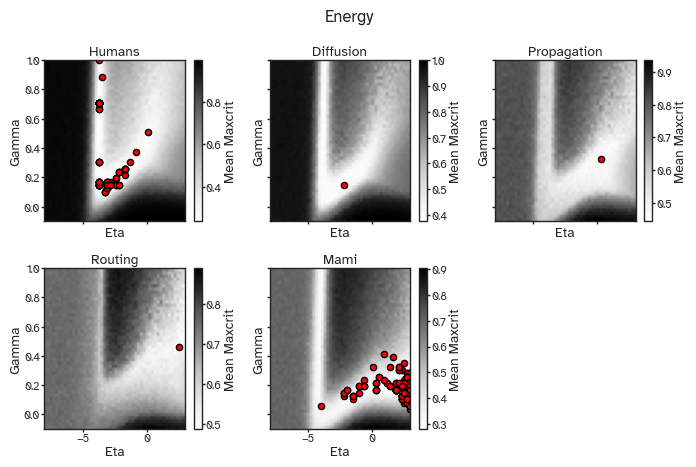

In [25]:
# distance_measure = "energy" # "hamming" # delta_con

# Store all minima for each network type
all_minima = {}

# Do this in subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

# Process each CSV file
for i, (network_name, get_csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    
    # Load the data
    df = pd.read_csv(get_csv_path)
    
    # Remove all "_x" and "_y" etc from the keys, and remove then all columns that have already appeared (exactly do this for "_x", "_y", "_z")
    # unique_keys = list(set([k.replace("_x", "").replace("_y", "").replace("_z", "")+"_x" for k in df.keys()]) - set(['eta_x', 'filename_x', 'id_x', 'gamma_x', 'network_index_x']))
    # unique_keys = unique_keys + ['eta', 'filename', 'id', 'gamma', 'network_index']
    # df = df[unique_keys]
    keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
    keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
    unique_keys = list(keys)
    unique_keys

    all_keys = set(df.keys())
    # Get the first column-name version for each unique key (e.g. "eta_x" for "eta", "gamma_x" for "gamma", etc.)
    first_versions = []
    for key in unique_keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break

    # print(len(first_versions), len(df.columns))

    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']] # 'filename', 
    
    # # Drop filename column if it exists
    # if 'filename' in df.columns:
    #     df.drop(columns=["filename"], inplace=True)
    
    print(len(df.keys()))
    
    # Group by eta and gamma and calculate mean
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    
    # Find minima for each subject (DeltaCon columns)
    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]

    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    minima_eta = []
    minima_gamma = []
    number_minima = []

    for col in distance_measure_columns:
        # Find the row with minimum DeltaCon for this subject
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])
        # Add the number of minimum values to an array 
        # number_minima.append(df_mean.loc[min_idx, "gamma"].to_numpy())
        # print(np.array(df_mean.loc[min_idx, "gamma"]).shape)

    all_minima[network_name] = {
        'eta': minima_eta,
        'gamma': minima_gamma,
        'df_mean': df_mean, 
        'number_minima': number_minima
    }
    print(f"  Found {len(minima_eta)} minima")
    
    cmap = "Grays"

    # CHANGE SCALING HERE: EITHER FROM 300 to 2300, or for every plot individually. 
    background = axs[i].imshow(df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"), 
                               extent=(df_mean["eta"].min(), df_mean["eta"].max(), df_mean["gamma"].min(), df_mean["gamma"].max()), 
                               origin='lower', aspect='auto', cmap=cmap) # , vmin=300, vmax=2300) # , alpha=0.5)
    
    
    axs[i].set_title(network_name.capitalize())
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Gamma") 
    plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

    # Add minima points
    axs[i].scatter(minima_eta, minima_gamma, color='red', s=20, label='Minima', edgecolor='black')

# Remove empty subplot
if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.suptitle(f"{distance_measure.capitalize()}") # .replace(" ", "")}")
plt.tight_layout()
# plt.savefig(base_dir / f"energy_all_datasets.pdf", bbox_inches="tight")
# print(base_dir / f"energy_all_datasets.pdf")


Processing humans...
104
  Found 100 minima
Processing diffusion...
5
  Found 1 minima
Processing propagation...
5
  Found 1 minima
Processing routing...
5
  Found 1 minima
Processing mami...
228
  Found 224 minima
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/energy_all_datasets.pdf
Processing humans...
104
  Found 100 minima
Processing diffusion...
5
  Found 1 minima
Processing propagation...
5
  Found 1 minima
Processing routing...
5
  Found 1 minima
Processing mami...
229
  Found 225 minima
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/delta_con_all_datasets.pdf
Processing humans...
104
  Found 0 minima
Processing diffusion...
5
  Found 0 minima
Processing propagation...
5
  Found 0 minima
Processing routing...
5
  Found 0 minima
Processing mami...
228
  Found 0 minima
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/frobenius_all_datasets.pdf


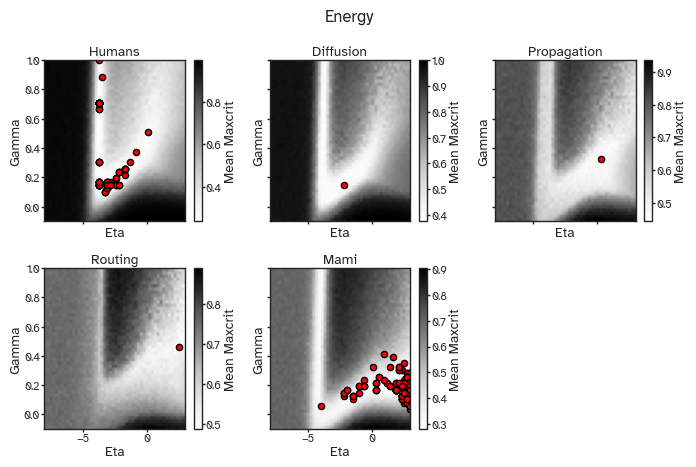

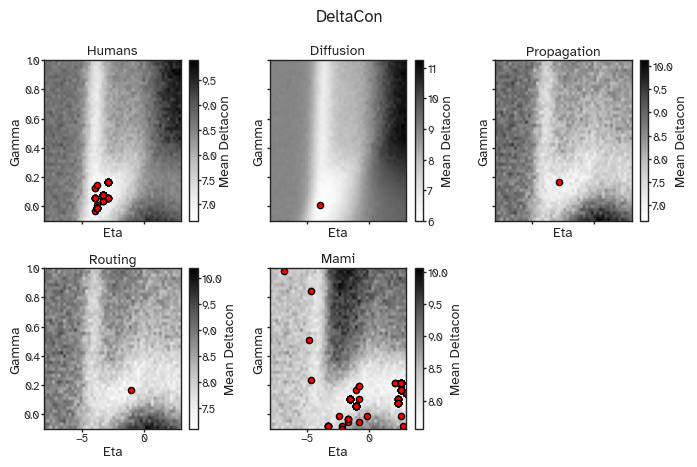

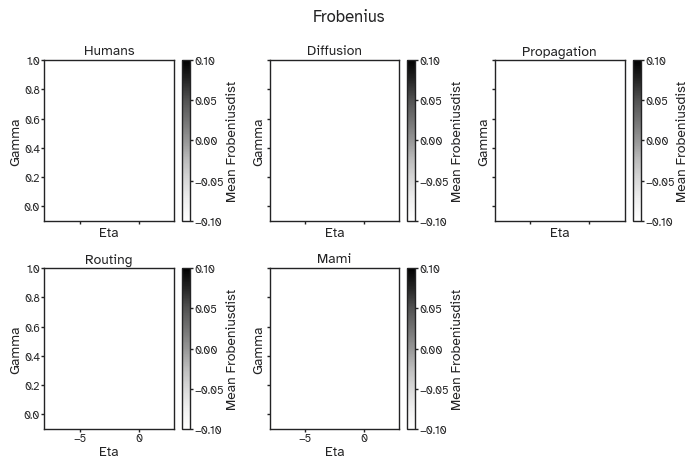

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from vizman import viz

base_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")

distance_name_in_csv_dict = {
        "hamming": "HammingDist", 
        "delta_con": "DeltaCon", 
        "energy": "MaxCrit", 
        "frobenius": "FrobeniusDist"
    }

names_of_distances = {"energy": "Energy", 
                      "delta_con": "DeltaCon", 
                      "frobenius": "Frobenius"} 

for distance_measure in ["energy", "delta_con", "frobenius"]:

    distance_name_in_csv = distance_name_in_csv_dict[distance_measure]

    csv_files = {
        'humans': base_dir / f"hcp_schaefer_100_dataset/05_mst_animal_0_compared_with_hcp_schaefer_100/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_hcp_schaefer_100.csv",
        'diffusion': base_dir / f"kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusion/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_diffusion.csv",
        'propagation': base_dir / f"kaysons_generated_networks_propagation/05_mst_animal_0_compared_with_propagation/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_propagation.csv",
        'routing': base_dir / f"kaysons_generated_networks_routing/05_mst_animal_0_compared_with_routing/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_routing.csv",
        'mami': base_dir / f"suarez_MaMI_dataset/05_mst_animal_0_compared_with_mami/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_mami.csv"
    }

    # Store all minima for each network type
    all_minima = {}

    # Do this in subplots
    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
    axs = axs.flatten()

    # Process each CSV file
    for i, (network_name, get_csv_path) in enumerate(csv_files.items()):
        print(f"Processing {network_name}...")
        
        # Load the data
        df = pd.read_csv(get_csv_path)

        keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
        keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
        unique_keys = list(keys)
        unique_keys

        all_keys = set(df.keys())
        # Get the first column-name version for each unique key (e.g. "eta_x" for "eta", "gamma_x" for "gamma", etc.)
        first_versions = []
        for key in unique_keys:
            for suffix in ["", "_x", "_y", "_z"]:
                candidate = key + suffix
                if candidate in all_keys:
                    first_versions.append(candidate)
                    break

        # print(len(first_versions), len(df.columns))

        df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']] # 'filename', 
        
        print(len(df.keys()))
        
        # Group by eta and gamma and calculate mean
        df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
        
        # Find minima for each subject (DeltaCon columns)
        distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]

        df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

        minima_eta = []
        minima_gamma = []
        number_minima = []

        for col in distance_measure_columns:
            # Find the row with minimum DeltaCon for this subject
            min_idx = df_mean[col].idxmin()
            minima_eta.append(df_mean.loc[min_idx, "eta"])
            minima_gamma.append(df_mean.loc[min_idx, "gamma"])

        all_minima[network_name] = {
            'eta': minima_eta,
            'gamma': minima_gamma,
            'df_mean': df_mean, 
            'number_minima': number_minima
        }
        print(f"  Found {len(minima_eta)} minima")
        
        cmap = "Grays"

        # CHANGE SCALING HERE: EITHER FROM 300 to 2300, or for every plot individually. 
        background = axs[i].imshow(df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"), 
                                extent=(df_mean["eta"].min(), df_mean["eta"].max(), df_mean["gamma"].min(), df_mean["gamma"].max()), 
                                origin='lower', aspect='auto', cmap=cmap) # , vmin=300, vmax=2300) # , alpha=0.5)
        
        
        axs[i].set_title(network_name.capitalize())
        axs[i].set_xlabel("Eta")
        axs[i].set_ylabel("Gamma") 
        plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

        # Add minima points
        axs[i].scatter(minima_eta, minima_gamma, color='red', s=20, label='Minima', edgecolor='black')

    # Remove empty subplot
    if len(csv_files) < len(axs):
        for j in range(len(csv_files), len(axs)):
            fig.delaxes(axs[j])

    plt.suptitle(f"{names_of_distances[distance_measure]}") # .replace(" ", "")}")
    plt.tight_layout()
    plt.savefig(base_dir / f"{distance_measure}_all_datasets.pdf", bbox_inches="tight")
    print(base_dir / f"{distance_measure}_all_datasets.pdf")


Processing humans...
104
  Found top 100 combinations
Processing diffusion...
5
  Found top 100 combinations
Processing propagation...
5
  Found top 100 combinations
Processing routing...
5
  Found top 100 combinations
Processing mami...
228
  Found top 100 combinations


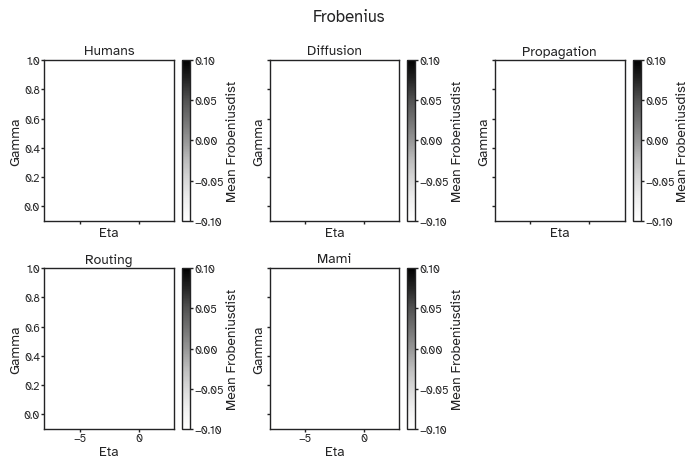

In [27]:
all_minima = {}

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

for i, (network_name, get_csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    df = pd.read_csv(get_csv_path)

    keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
    keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
    unique_keys = list(keys)

    all_keys = set(df.keys())
    first_versions = []
    for key in unique_keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break

    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']]
    print(len(df.keys()))

    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()

    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]
    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    # --- CHANGED: Select top 100 eta/gamma combinations by mean distance ---
    top100 = df_mean.nsmallest(100, f"{distance_name_in_csv}_mean")
    best_eta   = top100["eta"].tolist()
    best_gamma = top100["gamma"].tolist()
    best_scores = top100[f"{distance_name_in_csv}_mean"].tolist()
    # -----------------------------------------------------------------------

    all_minima[network_name] = {
        'eta': best_eta,
        'gamma': best_gamma,
        'df_mean': df_mean,
        'best_scores': best_scores
    }
    print(f"  Found top {len(best_eta)} combinations")

    cmap = "Grays"
    background = axs[i].imshow(
        df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"),
        extent=(df_mean["eta"].min(), df_mean["eta"].max(),
                df_mean["gamma"].min(), df_mean["gamma"].max()),
        origin='lower', aspect='auto', cmap=cmap
    )
    axs[i].set_title(network_name.capitalize())
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Gamma")
    plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

    # --- CHANGED: Plot top 100, coloured by their mean distance score ---
    sc = axs[i].scatter(
        best_eta, best_gamma,
        c=best_scores,          # colour encodes how good each point is
        cmap="RdYlGn_r",        # green = best (lowest), red = worst of the top-100
        s=20, edgecolor='black',
        label='Top 100', zorder=5
    )
    # plt.colorbar(sc, ax=axs[i], label="Score (top 100)")
    # -------------------------------------------------------------------

if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.suptitle(f"{distance_measure.capitalize()}")
plt.tight_layout()

Processing humans...
104
  Found top 100 combinations
Processing diffusion...
5
  Found top 100 combinations
Processing propagation...
5
  Found top 100 combinations
Processing routing...
5
  Found top 100 combinations
Processing mami...
228
  Found top 100 combinations


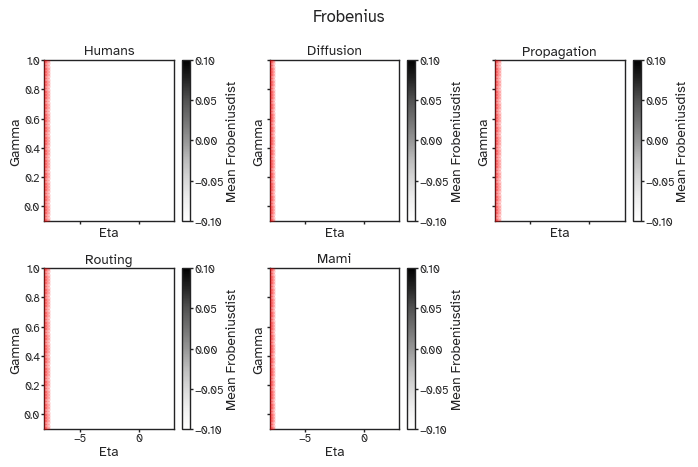

In [28]:
all_minima = {}

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

for i, (network_name, get_csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    df = pd.read_csv(get_csv_path)

    keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
    keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
    unique_keys = list(keys)

    all_keys = set(df.keys())
    first_versions = []
    for key in unique_keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break

    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']]
    print(len(df.keys()))

    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()

    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]
    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    # --- CHANGED: Select top 100 eta/gamma combinations by mean distance ---
    top100 = df_mean.nsmallest(100, f"{distance_name_in_csv}_mean")
    best_eta   = top100["eta"].tolist()
    best_gamma = top100["gamma"].tolist()
    best_scores = top100[f"{distance_name_in_csv}_mean"].tolist()
    # -----------------------------------------------------------------------

    all_minima[network_name] = {
        'eta': best_eta,
        'gamma': best_gamma,
        'df_mean': df_mean,
        'best_scores': best_scores
    }
    print(f"  Found top {len(best_eta)} combinations")

    cmap = "Grays"
    background = axs[i].imshow(
        df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"),
        extent=(df_mean["eta"].min(), df_mean["eta"].max(),
                df_mean["gamma"].min(), df_mean["gamma"].max()),
        origin='lower', aspect='auto', cmap=cmap
    )
    axs[i].set_title(network_name.capitalize())
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Gamma")
    plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

    # --- CHANGED: Plot top 100, coloured by their mean distance score ---
    sc = axs[i].scatter(
        best_eta, best_gamma,
        # c=best_scores,          # colour encodes how good each point is
        # cmap= # RdYlGn_r",        # green = best (lowest), red = worst of the top-100
        c="red", 
        s=20, 
        # edgecolor='black',#
        linewidth=0, 
        alpha=0.2,
        label='Top 100', zorder=5
    )
    # plt.colorbar(sc, ax=axs[i], label="Score (top 100)")
    # -------------------------------------------------------------------

if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.suptitle(f"{distance_measure.capitalize()}")
plt.tight_layout()

Processing humans...
104
  Found 0 minima


NameError: name 'vmin' is not defined

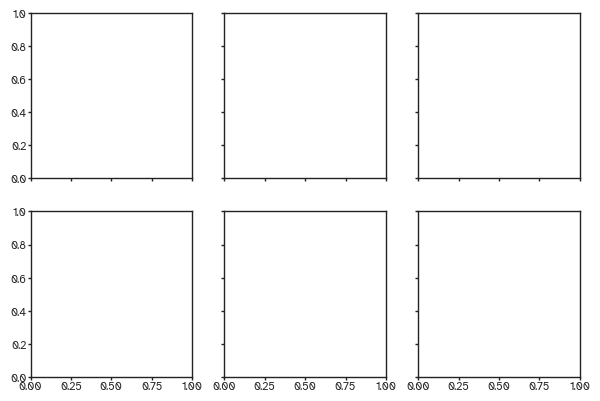

In [29]:

# Store all minima for each network type
all_minima = {}

# Do this in subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

# Process each CSV file
for i, (network_name, get_csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    
    # Load the data
    df = pd.read_csv(get_csv_path)
    
    # Remove all "_x" and "_y" etc from the keys, and remove then all columns that have already appeared (exactly do this for "_x", "_y", "_z")
    # unique_keys = list(set([k.replace("_x", "").replace("_y", "").replace("_z", "")+"_x" for k in df.keys()]) - set(['eta_x', 'filename_x', 'id_x', 'gamma_x', 'network_index_x']))
    # unique_keys = unique_keys + ['eta', 'filename', 'id', 'gamma', 'network_index']
    # df = df[unique_keys]
    keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
    keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
    unique_keys = list(keys)
    unique_keys

    all_keys = set(df.keys())
    # Get the first column-name version for each unique key (e.g. "eta_x" for "eta", "gamma_x" for "gamma", etc.)
    first_versions = []
    for key in unique_keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break

    # print(len(first_versions), len(df.columns))

    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']] # 'filename', 
    
    # # Drop filename column if it exists
    # if 'filename' in df.columns:
    #     df.drop(columns=["filename"], inplace=True)
    
    print(len(df.keys()))
    
    # Group by eta and gamma and calculate mean
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    
    # Find minima for each subject (DeltaCon columns)
    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]

    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    minima_eta = []
    minima_gamma = []
    number_minima = []

    for col in distance_measure_columns:
        # Find the row with minimum DeltaCon for this subject
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])
        # Add the number of minimum values to an array 
        # number_minima.append(df_mean.loc[min_idx, "gamma"].to_numpy())
        # print(np.array(df_mean.loc[min_idx, "gamma"]).shape)

    all_minima[network_name] = {
        'eta': minima_eta,
        'gamma': minima_gamma,
        'df_mean': df_mean, 
        'number_minima': number_minima
    }
    print(f"  Found {len(minima_eta)} minima")
    
    cmap = "Grays"

    # CHANGE SCALING HERE: EITHER FROM 300 to 2300, or for every plot individually. 
    if distance_measure == "delta_con": 
        vmin = 4
        vmax = 12 
    elif distance_measure == "hamming":
        vmin = 300
        vmax = 2300
    elif distance_measure == "energy":
        vmin = 0
        vmax = 1
    background = axs[i].imshow(df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"), 
                               extent=(df_mean["eta"].min(), df_mean["eta"].max(), df_mean["gamma"].min(), df_mean["gamma"].max()), 
                               origin='lower', aspect='auto', cmap=cmap,
                               vmin=vmin, vmax=vmax) # , alpha=0.5)


    axs[i].set_title(network_name.capitalize())
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Gamma") 
    plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

    # Add minima points
    axs[i].scatter(minima_eta, minima_gamma, color='red', s=20, label='Minima', edgecolor='black')
    # ax_min = axs[i].scatter(minima_eta, minima_gamma, c=number_minima, s=20, label='Minima', edgecolor='black', cmap="Reds")
    # axs[i].legend()
    
    
    # Add colorbar
    # norm = plt.Normalize(df_mean[f"{distance_name_in_csv}_mean"].min(), df_mean[f"{distance_name_in_csv}_mean"].max())
    # norm = plt.Normalize(300, 2300) # df_mean[f"{distance_name_in_csv}_mean"].min(), df_mean[f"{distance_name_in_csv}_mean"].max())
    # sm = plt.cm.ScalarMappable(cmap=cmap) # , norm=norm)
    # sm.set_array([])
    # fig.colorbar(sm, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")
    # plt.colorbar(ax_min, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

# Remove empty subplot
if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.suptitle(f"{distance_measure.capitalize()}")
plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_11194/2709138288.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,


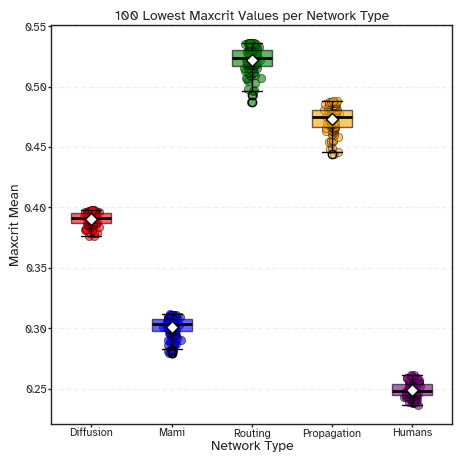


SUMMARY STATISTICS (100 LOWEST VALUES)

DIFFUSION:
  Min: 0.376000
  Q1 (25th percentile): 0.387000
  Median: 0.391000
  Q3 (75th percentile): 0.395250
  Max: 0.398000
  Mean ± std: 0.390621 ± 0.005403

MAMI:
  Min: 0.279385
  Q1 (25th percentile): 0.297623
  Median: 0.303259
  Q3 (75th percentile): 0.307697
  Max: 0.311402
  Mean ± std: 0.301308 ± 0.008014

ROUTING:
  Min: 0.487371
  Q1 (25th percentile): 0.516656
  Median: 0.523500
  Q3 (75th percentile): 0.530040
  Max: 0.536028
  Mean ± std: 0.522200 ± 0.010613

PROPAGATION:
  Min: 0.444000
  Q1 (25th percentile): 0.466699
  Median: 0.475000
  Q3 (75th percentile): 0.481000
  Max: 0.488000
  Mean ± std: 0.472999 ± 0.010247

HUMANS:
  Min: 0.235980
  Q1 (25th percentile): 0.244788
  Median: 0.247980
  Q3 (75th percentile): 0.253593
  Max: 0.261160
  Mean ± std: 0.248904 ± 0.005986


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Collect the 100 lowest DeltaCon values for each network type
boxplot_data = []
labels = []

colors_list = ['red', 'blue', 'green', 'orange', 'purple']
network_types = ['diffusion', 'mami', 'routing', 'propagation', 'humans']

for network_name in network_types:
    df_mean = all_minima[network_name]['df_mean']
    
    # Ensure DeltaCon_mean exists
    if f'{distance_name_in_csv}_mean' not in df_mean.columns:
        distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]
        df_mean[f'{distance_name_in_csv}_mean'] = df_mean[distance_measure_columns].mean(axis=1)

    # Get the 100 lowest values from the ENTIRE dataframe
    lowest_100 = df_mean[f'{distance_name_in_csv}_mean'].nsmallest(100).values
    boxplot_data.append(lowest_100)
    labels.append(network_name.capitalize())

# Create the boxplot
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12,12)), dpi=100)

bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,
                showmeans=True, meanline=False,
                medianprops=dict(color='black', linewidth=2),
                meanprops=dict(marker='D', markerfacecolor='white', 
                              markeredgecolor='black', markersize=6))

# Add scatter points for the 100 lowest values
for i, data in enumerate(boxplot_data):
    x = np.random.normal(i + 1, 0.04, size=len(data))  # Jitter the x-values
    ax.scatter(x, data, color=colors_list[i], alpha=0.6, edgecolor='black', linewidth=0.5)

# Color the boxes
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel(f'{distance_name_in_csv.capitalize()} Mean')
ax.set_xlabel('Network Type')
ax.set_title(f'100 Lowest {distance_name_in_csv.capitalize()} Values per Network Type')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary statistics for the 100 lowest values
print("\n" + "="*60)
print("SUMMARY STATISTICS (100 LOWEST VALUES)")
print("="*60)
for i, network_name in enumerate(network_types):
    data = boxplot_data[i]
    print(f"\n{network_name.upper()}:")
    print(f"  Min: {np.min(data):.6f}")
    print(f"  Q1 (25th percentile): {np.percentile(data, 25):.6f}")
    print(f"  Median: {np.median(data):.6f}")
    print(f"  Q3 (75th percentile): {np.percentile(data, 75):.6f}")
    print(f"  Max: {np.max(data):.6f}")
    print(f"  Mean ± std: {np.mean(data):.6f} ± {np.std(data):.6f}")